# ResOSc — New Features Demo

This notebook demonstrates the three additions to the ResOSc package:

1. **Force-model selection** — strain (GW), uniform momentum-impulse (DM), and custom spatial profiles via `compute_forces(force_model=...)`.
2. **Non-interacting reference system & frequency-spread analysis** via `reference_system()` and `frequency_spread()`.
3. **Sensitivity normalisation** against the uncoupled minimax benchmark via `normalized_sensitivity_profile()` and the `reference` argument to `compare_observables()`.

The original package demo (`ResOSc_demo.ipynb`) is unchanged.

## Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from ResOSc import CoupledSystem                                    # type: ignore
from ResOSc.plotting import setup_plot_style                        # type: ignore
from ResOSc.observables import (                                    # type: ignore
    coupling_heatmap, find_minimum_observables,
    optimize_observable, compare_observables,
    normalized_sensitivity_profile,
)

## System Setup

We reuse the same 10-oscillator system from the original demo so results are directly comparable.

In [7]:
sys = CoupledSystem(n=10)
sys.set_masses([0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90])
sys.set_springs(
    wall = [1.2] * 10,
    coupling= [0.1] * 9,
)
sys.set_damping(gamma=0.01)
sys.solve()

L  = 1.0   # apparatus length
h0 = 1.0   # signal amplitude

import os
save_plots = 'figures-new'

def fig_path(name):
    if save_plots is None:
        return None
    os.makedirs(save_plots, exist_ok=True)
    return os.path.join(save_plots, name)

setup_plot_style()
print(f'Normal frequencies: {np.array2string(sys.frequencies, precision=4)}')

Normal frequencies: [1.7583 1.6596 1.5917 1.5271 1.4676 1.4142 1.3653 1.3162 1.2586 1.1766]


---
# 1. Force-Model Selection

`compute_forces()` now accepts a `force_model` keyword:

| Model | Force on oscillator $i$ | Physical scenario |
|---|---|---|
| `'strain'` *(default)* | $f_i = h_0 L \, k_{ii}$ | GW tidal force — proportional to local wall-spring stiffness |
| `'uniform'` | $f_i = h_0 L$ | Dark-matter momentum impulse — identical kick on every mass |
| `'custom'` | $f_i = h_0 \, v_i$ | Coherent DM wave, position-dependent coupling, etc. |

The physically important quantity is the **generalized force** $q_\alpha = \sum_j A_{\alpha j} f_j$ projected onto each normal mode.

**Key qualitative difference:** for a symmetric array driven *uniformly*, antisymmetric modes satisfy $\sum_j A_{\alpha j} \approx 0$, so the DM impulse concentrates signal in the centre-of-mass-like mode and leaves antisymmetric modes nearly undriven — the opposite of the GW case where stiffer oscillators are driven harder.

In [8]:
# Oscillator positions along the chain (unit spacing)
positions = np.arange(sys.n, dtype=float)

# ── 1a. Strain (GW) ───────────────────────────────────────────────────────
sys.compute_forces(L=L, h0=h0, force_model='strain')
q_strain     = sys.q.copy()
peaks_strain = sys.peak_sensitivities()

# ── 1b. Uniform momentum impulse (DM) ────────────────────────────────────
sys.compute_forces(L=L, h0=h0, force_model='uniform')
q_uniform     = sys.q.copy()
peaks_uniform = sys.peak_sensitivities()

# ── 1c. Coherent DM wave: f_i = h0 * L * cos(k_DM * x_i) ────────────────
# k_DM = pi/(n+1) ensures no oscillator sits exactly at a force node
# (i.e. cos(k_DM * x_i) != 0 for all i), which keeps the reference
# sensitivities well-defined for the normalisation in Section 3.
k_DM          = np.pi / (sys.n + 1)
force_profile = L * np.cos(k_DM * positions)
sys.compute_forces(h0=h0, force_model='custom', force_vec=force_profile)
q_custom     = sys.q.copy()
peaks_custom = sys.peak_sensitivities()

# ── Print table ───────────────────────────────────────────────────────────
print(f"{'Mode':<6} {'omega*':>8} {'q (strain)':>12} {'q (uniform)':>13} {'q (coherent)':>14}")
print('─' * 57)
for i in range(sys.n):
    print(f"{i:<6} {sys.frequencies[i]:>8.4f}"
          f" {q_strain[i]:>12.4f} {q_uniform[i]:>13.4f} {q_custom[i]:>14.4f}")

Mode     omega*   q (strain)   q (uniform)   q (coherent)
─────────────────────────────────────────────────────────
0        1.7583      -0.2465       -0.2054        -0.2075
1        1.6596      -0.7177       -0.5981        -0.6154
2        1.5917       1.0294        0.8579         0.8641
3        1.5271      -1.0410       -0.8675        -0.8157
4        1.4676       1.0278        0.8565         0.7031
5        1.4142      -1.0257       -0.8548        -0.5588
6        1.3653       1.0568        0.8807         0.3893
7        1.3162       1.1654        0.9712         0.1747
8        1.2586       1.4824        1.2353        -0.2516
9        1.1766       1.8526        1.5438        -1.1027


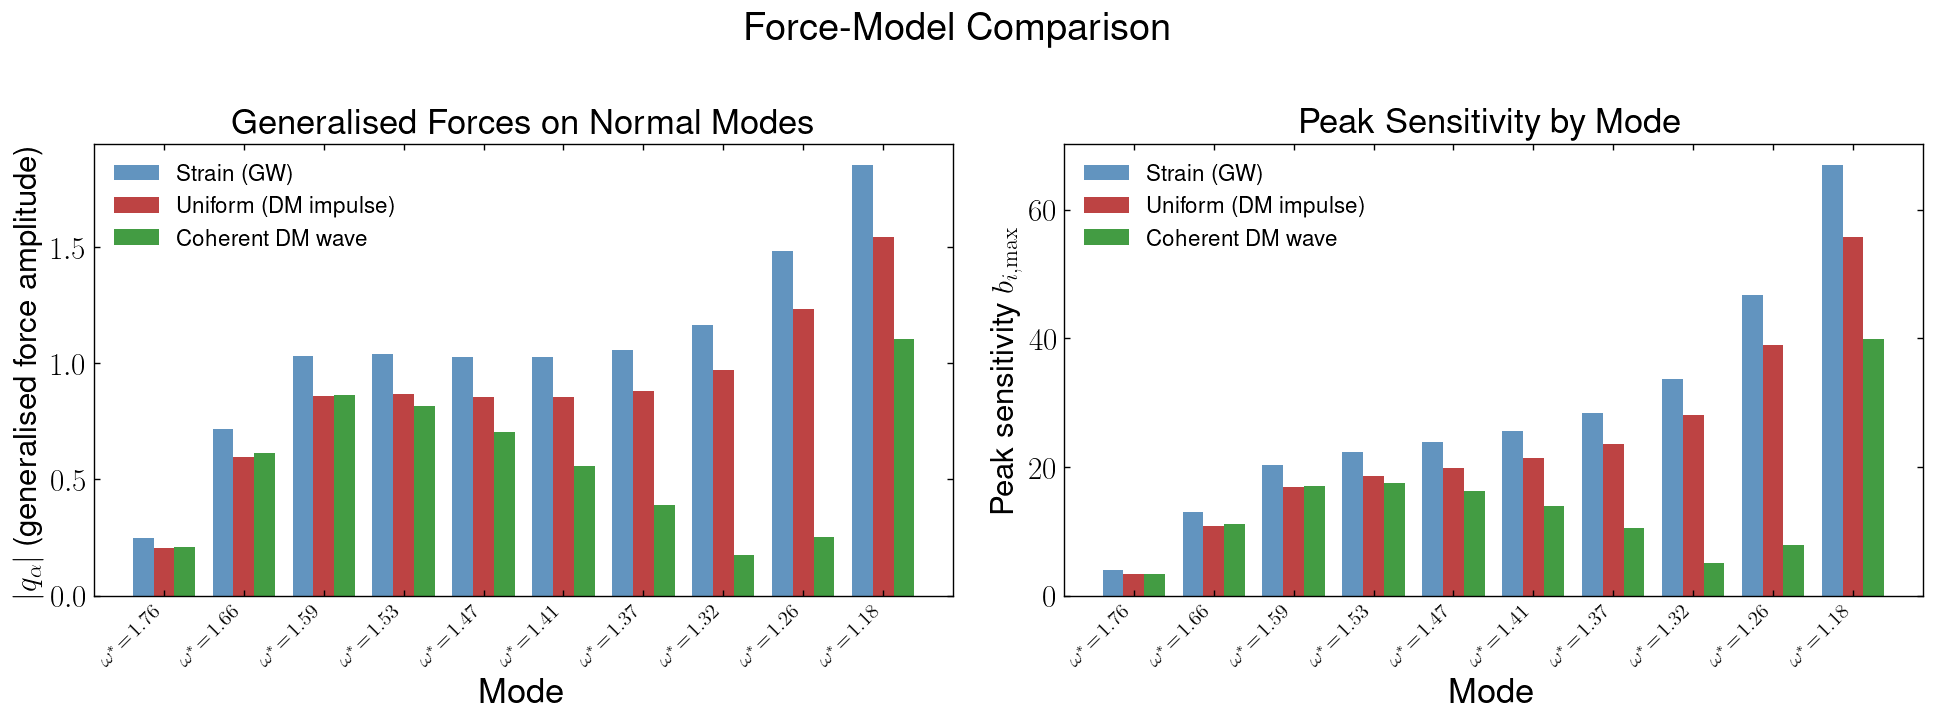

array([-0.24649077, -0.71768272,  1.0294258 , -1.04099978,  1.02781691,
       -1.02572366,  1.05679013,  1.1653988 ,  1.48240951,  1.85260077])

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=125)
x_pos  = np.arange(sys.n)
w      = 0.26
colors = ['steelblue', 'firebrick', 'forestgreen']
labels = ['Strain (GW)', 'Uniform (DM impulse)', 'Coherent DM wave']

# Left panel — |q_alpha|
for k, (q, col, lab) in enumerate(zip([q_strain, q_uniform, q_custom], colors, labels)):
    axes[0].bar(x_pos + (k - 1) * w, np.abs(q), w, label=lab, color=col, alpha=0.85)
axes[0].set_xlabel(r'Mode', fontsize=20)
axes[0].set_ylabel(r'$|q_\alpha|$  (generalised force amplitude)', fontsize=18)
axes[0].set_title(r'Generalised Forces on Normal Modes', fontsize=20)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([fr'$\omega^*\!=\!{sys.frequencies[i]:.2f}$' for i in range(sys.n)],
                         rotation=45, ha='right', fontsize=12)
axes[0].legend(frameon=False, fontsize=13)
axes[0].tick_params(direction='in', top=True, right=True)

# Right panel — peak sensitivity b_{i,max}
for k, (p, col, lab) in enumerate(zip([peaks_strain, peaks_uniform, peaks_custom], colors, labels)):
    axes[1].bar(x_pos + (k - 1) * w, p, w, label=lab, color=col, alpha=0.85)
axes[1].set_xlabel(r'Mode', fontsize=20)
axes[1].set_ylabel(r'Peak sensitivity $b_{i,\max}$', fontsize=18)
axes[1].set_title(r'Peak Sensitivity by Mode', fontsize=20)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([fr'$\omega^*\!=\!{sys.frequencies[i]:.2f}$' for i in range(sys.n)],
                         rotation=45, ha='right', fontsize=12)
axes[1].legend(frameon=False, fontsize=13)
axes[1].tick_params(direction='in', top=True, right=True)

plt.suptitle(r'Force-Model Comparison', fontsize=22)
plt.tight_layout()
if save_plots:
    fig.savefig(fig_path('force_model_comparison.pdf'), format='pdf',
                bbox_inches='tight', pad_inches=0.10)
plt.show()

# Restore strain model so subsequent cells are in a clean state
sys.compute_forces(L=L, h0=h0, force_model='strain')

---
# 2. Non-Interacting Reference System & Frequency Spread

## 2a. Reference System

`reference_system()` returns a solved copy of the system with all coupling springs set to zero.
Its eigenvector matrix is the identity — each oscillator is its own normal mode with bare frequency

$$\omega_i^0 = \sqrt{k_{ii}/m_i}$$

This reference serves two purposes:
- **Frequency-spread baseline**: how much of the final bandwidth comes from varied wall springs vs. from coupling?
- **Sensitivity normalization**: what is the best sensitivity the uncoupled sensors can achieve? (Section 3.)

In [10]:
# Build and solve the non-interacting reference
ref = sys.reference_system()
ref.compute_forces(L=L, h0=h0, force_model='strain')

print('Non-interacting reference — bare oscillator frequencies:')
print(f'  {np.array2string(ref.frequencies, precision=4)}\n')
print('Coupled system — normal-mode frequencies:')
print(f'  {np.array2string(sys.frequencies, precision=4)}\n')
print('Coupling shifts and mixes the degenerate bare frequencies into the band above.')

Non-interacting reference — bare oscillator frequencies:
  [1.633  1.5492 1.4771 1.4142 1.3587 1.3093 1.2649 1.2247 1.1882 1.1547]

Coupled system — normal-mode frequencies:
  [1.7583 1.6596 1.5917 1.5271 1.4676 1.4142 1.3653 1.3162 1.2586 1.1766]

Coupling shifts and mixes the degenerate bare frequencies into the band above.


## 2b. Frequency-Spread Metrics

`frequency_spread(reference=ref)` returns a dict with:

| Key | Meaning |
|---|---|
| `'absolute'` | $\omega_{max} - \omega_{min}$: detector bandwidth (the physically relevant number) |
| `'relative'` | Absolute spread / geometric-mean frequency: dimensionless, comparable across systems |
| `'spacing_uniformity'` | CV of consecutive spacings: 0 = uniform grid, larger = clustered modes |
| `'absolute_gain'` | Extra bandwidth introduced by the coupling springs alone |
| `'relative_gain'` | Ratio of relative spreads (coupled / reference); $> 1$ means coupling widens the band |

**For a detector**, only the absolute spread of the final normal modes matters for bandwidth coverage.
The non-interacting spread is not directly observable once the system is coupled.
`absolute_gain` and `relative_gain` quantify how much of the bandwidth is *coupling-induced*,
which is useful for tuning: if the gain is large, adjusting coupling in situ is an efficient knob.

In [11]:
spread     = sys.frequency_spread(reference=ref)
ref_spread = ref.frequency_spread()

header = f"{'Metric':<28} {'Coupled':>10} {'Reference':>12}"
sep    = '─' * len(header)
rows = [
    ('Absolute spread',         spread['absolute'],           ref_spread['absolute']),
    ('Relative spread',         spread['relative'],           ref_spread['relative']),
    ('Spacing uniformity (CV)', spread['spacing_uniformity'], ref_spread['spacing_uniformity']),
    ('omega_min',               spread['omega_min'],          ref_spread['omega_min']),
    ('omega_max',               spread['omega_max'],          ref_spread['omega_max']),
]
print(header); print(sep)
for label, v_c, v_r in rows:
    v_r_str = f'{v_r:>12.4f}' if np.isfinite(v_r) else f"{'—':>12}"
    print(f'{label:<28} {v_c:>10.4f} {v_r_str}')
print(sep)
print(f'\n  Absolute gain from coupling : {spread["absolute_gain"]:+.4f}')
rg = spread.get('relative_gain', float('nan'))
if np.isfinite(rg):
    print(f'  Relative bandwidth ratio    : {rg:.4f}x')
else:
    print('  Relative bandwidth ratio    : — (reference spread is zero; all wall springs equal)')

Metric                          Coupled    Reference
────────────────────────────────────────────────────
Absolute spread                  0.5816       0.4783
Relative spread                  0.4030       0.3545
Spacing uniformity (CV)          0.2400       0.3021
omega_min                        1.1766       1.1547
omega_max                        1.7583       1.6330
────────────────────────────────────────────────────

  Absolute gain from coupling : +0.1033
  Relative bandwidth ratio    : 1.1369x


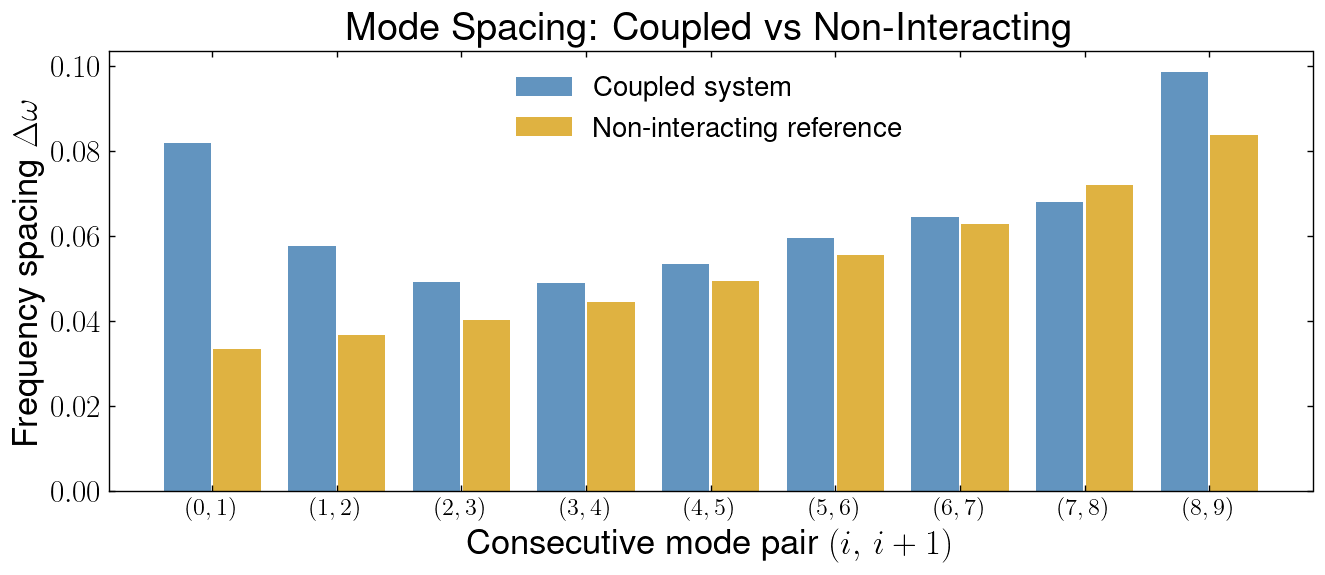

In [12]:
fig, ax = plt.subplots(figsize=(11, 5), dpi=125)
x_pos = np.arange(sys.n - 1)

ax.bar(x_pos - 0.2, spread['spacings'],     0.38,
       label=r'Coupled system',            color='steelblue', alpha=0.85)
ax.bar(x_pos + 0.2, ref_spread['spacings'], 0.38,
       label=r'Non-interacting reference', color='goldenrod', alpha=0.85)

ax.set_xlabel(r'Consecutive mode pair $(i,\,i+1)$', fontsize=20)
ax.set_ylabel(r'Frequency spacing $\Delta\omega$',   fontsize=20)
ax.set_title(r'Mode Spacing: Coupled vs Non-Interacting', fontsize=22)
ax.set_xticks(x_pos)
ax.set_xticklabels([fr'$({i},{i+1})$' for i in range(sys.n - 1)], fontsize=14)
ax.tick_params(direction='in', top=True, right=True)
ax.legend(frameon=False, fontsize=16)
plt.tight_layout()
if save_plots:
    fig.savefig(fig_path('frequency_spread.pdf'), format='pdf',
                bbox_inches='tight', pad_inches=0.10)
plt.show()

---
# 3. Sensitivity Normalisation Against the Reference

To judge whether coupling genuinely improves sensitivity, we compare against the
**minimax-optimal sensitivity of the non-interacting reference** — the best worst-case
sensitivity achievable with *any* linear combination of the uncoupled oscillator readouts:

$$\text{ref\_scale} = \frac{1}{\displaystyle\sqrt{\sum_i \dfrac{1}{b_{i,\text{ref}}^2}}}$$

For uniform reference sensitivities $b_\text{ref}$, this equals $b_\text{ref}/\sqrt{n}$.

Passing `reference=ref` to `compare_observables()`:
- Draws a gold dashed horizontal line at `ref_scale` on the plot.
- Adds `normalized_best_single_min` and `normalized_optimal_min_sensitivity` to the returned dict.

A normalised worst-case sensitivity $> 1$ means the coupled system outperforms the best uncoupled observable.

> **Note on the custom force model:** if any oscillator sits exactly at a force node ($f_i = 0$), its reference sensitivity is zero, and `ref_scale` is undefined ($\to 0$). This is avoided here by choosing $k_\mathrm{DM} = \pi/(n+1)$ so no position in the array is at a node.

## 3a. GW Strain Model

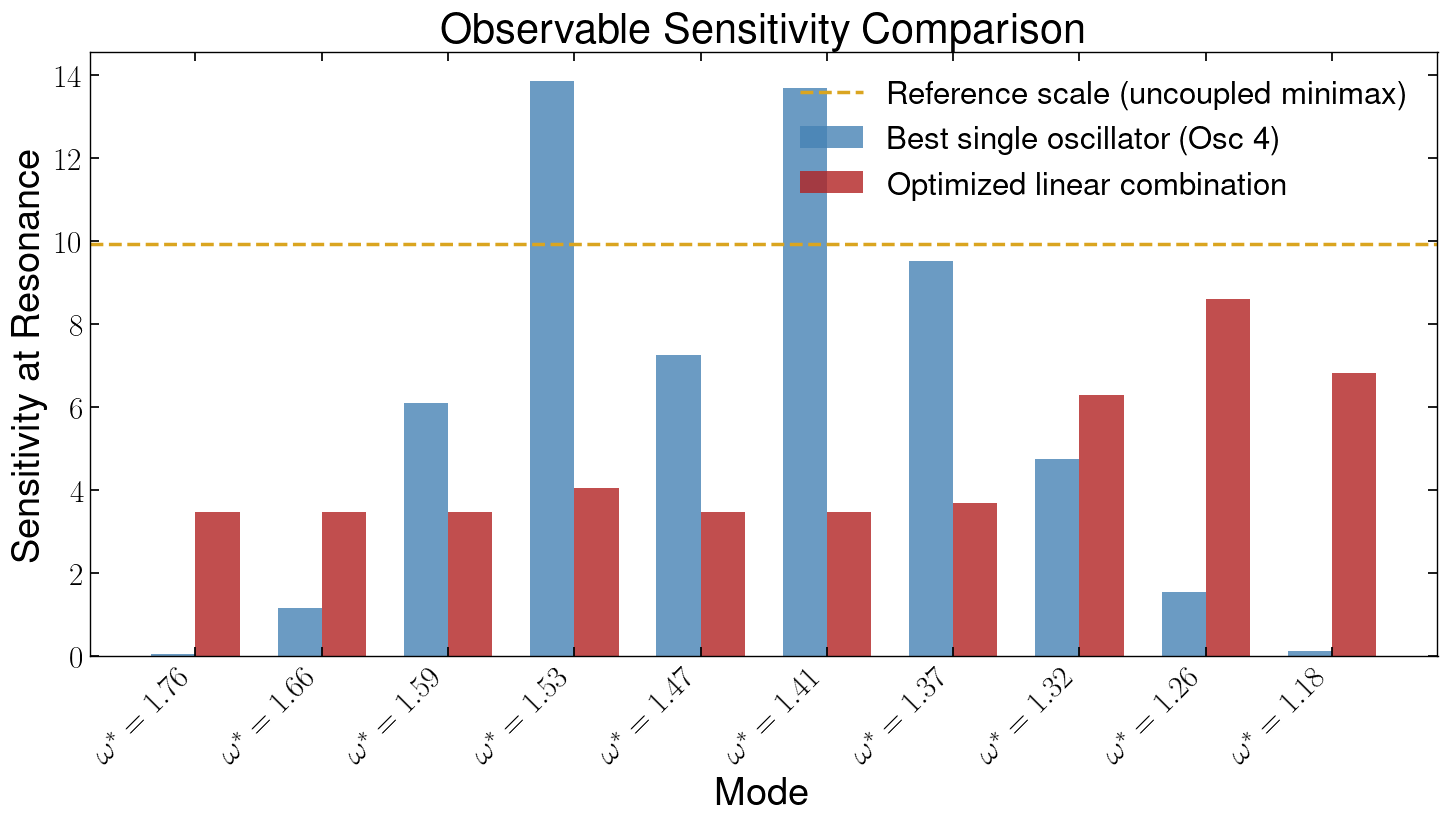

Reference scale (uncoupled minimax) : 9.9232

Best single oscillator (Osc 4):
  Worst-case sensitivity  : 0.0489
  Normalised              : 0.0049

Optimised linear combination:
  Worst-case sensitivity  : 3.4685
  Normalised              : 0.3495


In [13]:
sys.compute_forces(L=L, h0=h0, force_model='strain')
ref.compute_forces(L=L, h0=h0, force_model='strain')

comp_gw = compare_observables(sys, reference=ref,
                               savefig=fig_path('observable_comparison_gw.pdf'))

print(f"Reference scale (uncoupled minimax) : {comp_gw['ref_scale']:.4f}")
print(f"\nBest single oscillator (Osc {comp_gw['best_single_oscillator']}):")
print(f"  Worst-case sensitivity  : {np.min(comp_gw['best_single_sensitivities']):.4f}")
print(f"  Normalised              : {comp_gw['normalized_best_single_min']:.4f}")
print(f"\nOptimised linear combination:")
print(f"  Worst-case sensitivity  : {np.min(comp_gw['optimal_sensitivities']):.4f}")
print(f"  Normalised              : {comp_gw['normalized_optimal_min_sensitivity']:.4f}")

## 3b. DM Uniform Momentum Model

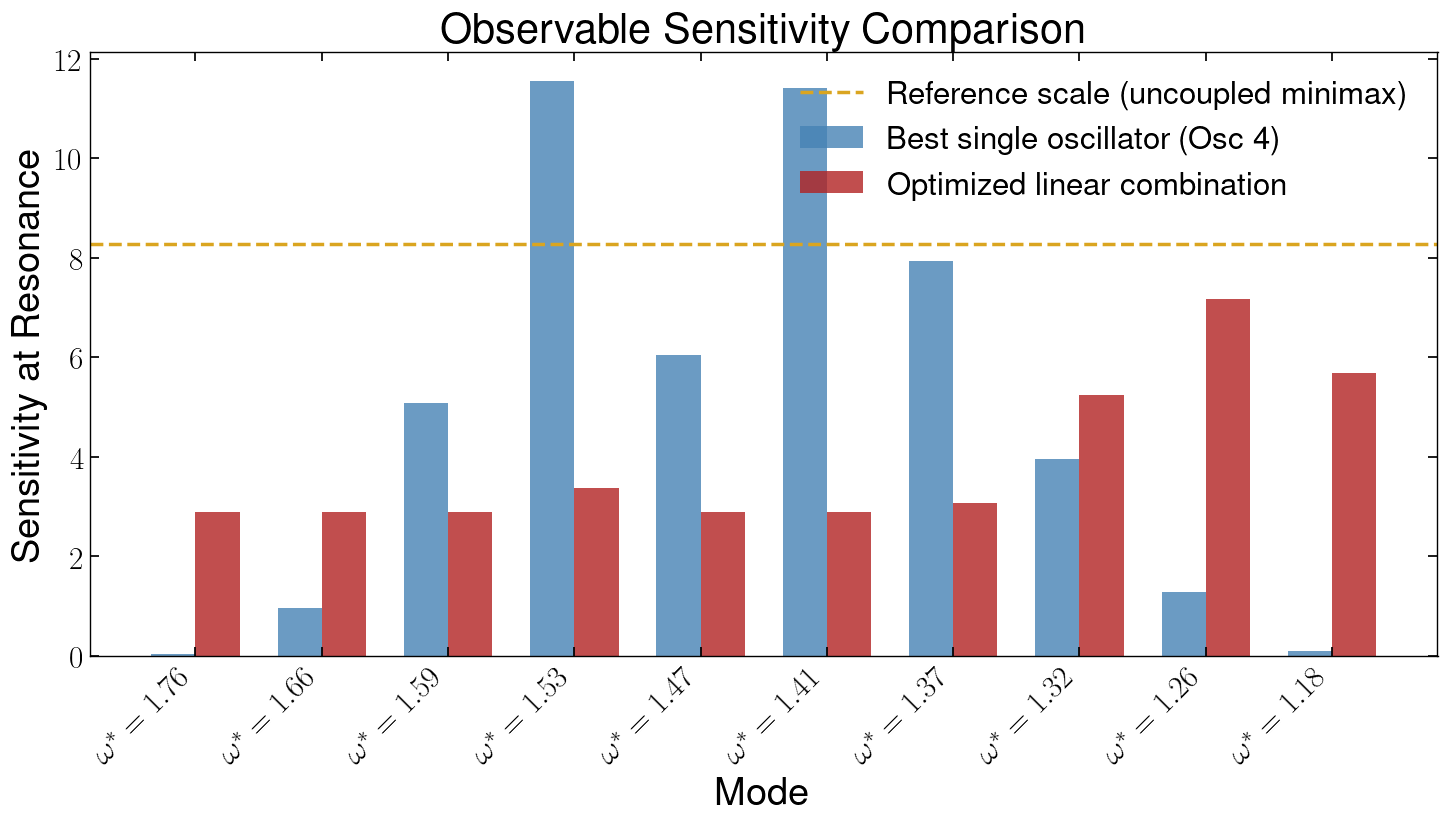

Reference scale (uncoupled minimax) : 8.2693

Best single oscillator (Osc 4):
  Worst-case sensitivity  : 0.0407
  Normalised              : 0.0049

Optimised linear combination:
  Worst-case sensitivity  : 2.8904
  Normalised              : 0.3495


In [14]:
sys.compute_forces(L=L, h0=h0, force_model='uniform')
ref.compute_forces(L=L, h0=h0, force_model='uniform')

comp_dm = compare_observables(sys, reference=ref,
                               savefig=fig_path('observable_comparison_dm.pdf'))

print(f"Reference scale (uncoupled minimax) : {comp_dm['ref_scale']:.4f}")
print(f"\nBest single oscillator (Osc {comp_dm['best_single_oscillator']}):")
print(f"  Worst-case sensitivity  : {np.min(comp_dm['best_single_sensitivities']):.4f}")
print(f"  Normalised              : {comp_dm['normalized_best_single_min']:.4f}")
print(f"\nOptimised linear combination:")
print(f"  Worst-case sensitivity  : {np.min(comp_dm['optimal_sensitivities']):.4f}")
print(f"  Normalised              : {comp_dm['normalized_optimal_min_sensitivity']:.4f}")

## 3c. Cross-Model Summary

The table below collects normalised minimax sensitivities for all three force models.

- **Below 1**: for the hardest-to-detect mode, coupling plus the optimised observable has not yet recovered the reference sensitivity.  The force model concentrates the signal in a subset of modes, leaving others weakly driven.
- **Above 1**: the coupled system with optimised weights beats the best any linear uncoupled observable can do.

In [15]:
# Coherent DM wave (k_DM = pi/(n+1), same as Section 1)
sys.compute_forces(h0=h0, force_model='custom', force_vec=force_profile)
ref.compute_forces(h0=h0, force_model='custom', force_vec=force_profile)
opt_coherent = optimize_observable(sys, reference=ref)

rows = [
    ('GW Strain',        comp_gw['normalized_optimal_min_sensitivity']),
    ('DM Uniform',       comp_dm['normalized_optimal_min_sensitivity']),
    ('DM Coherent wave', opt_coherent['normalized_min_sensitivity']),
]

print(f"\n{'Force model':<22} {'Normalised worst-case S':>24}")
print('─' * 52)
for label, val in rows:
    flag = '  > 1: coupling helps' if val > 1 else '  < 1: below reference'
    print(f"  {label:<20} {val:>20.4f}{flag}")
print('─' * 52)
print('\nAll values are relative to the uncoupled minimax reference scale.')

# Restore strain model as default state
sys.compute_forces(L=L, h0=h0, force_model='strain')


Force model             Normalised worst-case S
────────────────────────────────────────────────────
  GW Strain                          0.3495  < 1: below reference
  DM Uniform                         0.3495  < 1: below reference
  DM Coherent wave                   0.7874  < 1: below reference
────────────────────────────────────────────────────

All values are relative to the uncoupled minimax reference scale.


array([-0.24649077, -0.71768272,  1.0294258 , -1.04099978,  1.02781691,
       -1.02572366,  1.05679013,  1.1653988 ,  1.48240951,  1.85260077])